# Gene Expression Simulation

Cassiopeia can also be used to overlay simulated gene expression on top of a lineage tree. This can be used to test the performance of various methods for inferring gene expression dynamics from single-cell data, such as optimal transport or pseudotime analysis.

In [53]:
import matplotlib.pyplot as plt
import networkx as nx
import pycea as py
import scanpy as sc
import treedata as td

import cassiopeia as cas

## Tree simulation

First, we need to simulate a lineage tree which we can do with {func}`cassiopeia.sim.birth_death_process`. We have set `alignment = 'nodes'` so that the {class}`td.TreeData` object includes observations (`obs`) for all internal and leaf nodes. This allows us to visualize the gene expression dynamics on the tree in this tutorial, but in practice, you may want to set `alignment = 'leaves'` to only include observations for the leaf nodes.

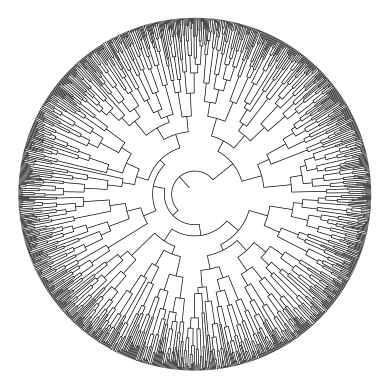

In [36]:
tdata = cas.sim.birth_death_process(num_extant=1000, alignment="nodes")
py.pl.tree(tdata, polar=True, depth_key="time");

## Brownian motion simulation


Next, let's simulate gene expression along the lineage tree using {func}`cassiopeia.sim.brownian_expression`. This method models gene expression as a Brownian motion process in a low-dimensional latent space, causing cells with a recent common ancestor to have similar expression profiles while allowing differences to accumulate over time.

At each branch, descendant cells inherit the latent state of their parent and undergo Brownian perturbations. The `momentum` parameter controls how strongly these changes persist across generations, with larger values producing smoother and more directional expression trajectories.

Once the latent states have been simulated, they are projected into gene space by multiplying them by a randomly generated loading matrix. The resulting gene expression values are then used directly (`"gaussian"`) or passed through a count-generating observation model (`"poisson"` or `"negative_binomial"`), allowing the simulation to produce either continuous expression values or realistic single-cell count data.

In [34]:
brownian_tdata = cas.sim.brownian_expression(
    tdata, n_genes=5000, distribution="gaussian", momentum=0.8
)
brownian_tdata

TreeData object with n_obs × n_vars = 2000 × 5000
    obs: 'tree', 'birth_scale', 'time'
    uns: 'default_depth'
    obsm: 'X_latent'
    obst: 'simulated'

We now have a {class}`td.TreeData` object with 2000 cells and 5000 cells. Let's use [Scanpy](https://scanpy.readthedocs.io/en/stable/) to visualize the simulated gene expression data and perform leiden clustering.

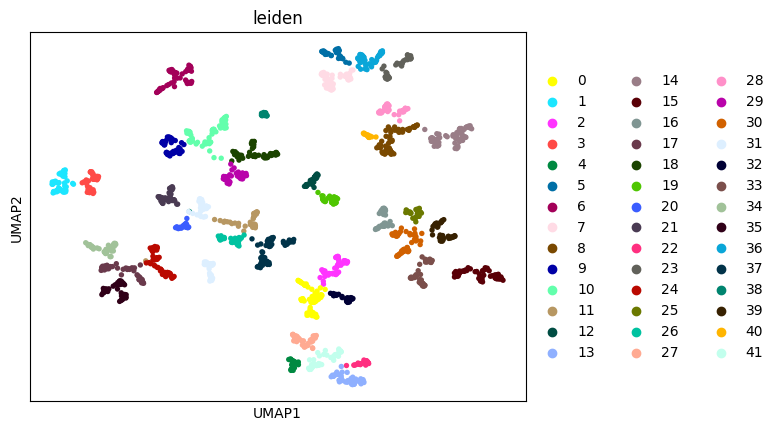

In [4]:
sc.pp.pca(brownian_tdata)
sc.pp.neighbors(brownian_tdata)
sc.tl.umap(brownian_tdata)
sc.tl.leiden(brownian_tdata, flavor="igraph")
sc.pl.umap(brownian_tdata, color="leiden")

We can also plot the leiden cluster on the lineage tree

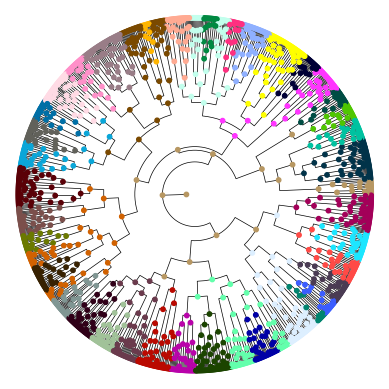

In [ ]:
py.pl.tree(brownian_tdata, polar=True, node_color="leiden", nodes="all", depth_key="time");

## Trajectory simulation

However, gene expression dynamics are often not well captured by a Brownian motion process. For example, in development, gene programs are recurrently activated across the embryo as progenitor populations progress through shared cell-state trajectories and branch toward different fates.

To model this setting, Cassiopeia provides {func}`cassiopeia.sim.trajectory_expression`, which overlays gene expression onto a lineage tree by mapping each cell to a position along a predefined cell-state trajectory. In this model, the lineage tree determines when each cell exists, while the trajectory determines what transcriptional state the cell occupies at that time.

Unlike Brownian motion, where each lineage drifts freely through latent space, the trajectory model constrains cells to move along shared paths. Branch points in the trajectory represent fate decisions, allowing related cells to share expression dynamics until their ancestors commit to different branches.

After each cell is assigned a position on the trajectory, its latent expression state is computed by interpolating between the latent vectors of the corresponding trajectory nodes. Optional latent noise can then be added before projecting the latent states into gene space with a random loading matrix and applying the selected observation model.

A simple way to construct a trajectory is with the {func}`cassiopeia.sim.brownian_expression` function. Here we simulate a trajectory with 8 terminal fates, and then use this trajectory to simulate gene expression on the lineage tree.

In [54]:
basic_trajectory = cas.sim.complete_binary(8, alignment="nodes")
basic_trajectory = cas.sim.brownian_expression(basic_trajectory, momentum=0.95)
trajectory_data = cas.sim.trajectory_expression(tdata, basic_trajectory, latent_noise=0.2)
trajectory_data

TreeData object with n_obs × n_vars = 2000 × 5000
    obs: 'tree', 'birth_scale', 'time'
    uns: 'default_depth'
    obsm: 'X_latent'
    obst: 'simulated'

Again we have a {class}`td.TreeData` object with 2000 cells and 5000 cells which we can visualize with [Scanpy](https://scanpy.readthedocs.io/en/stable/).

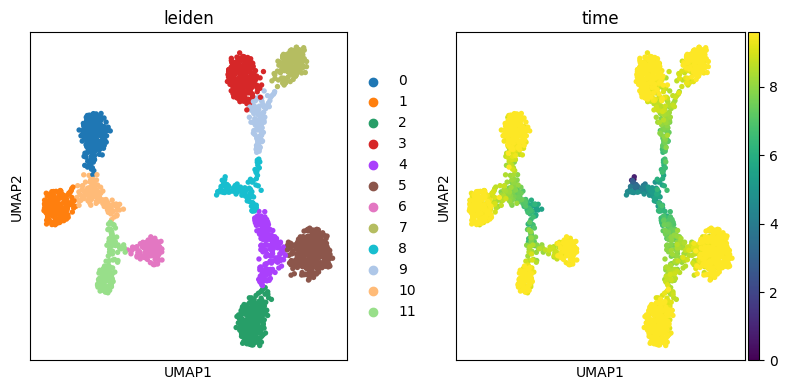

In [56]:
sc.pp.pca(trajectory_data)
sc.pp.neighbors(trajectory_data)
sc.tl.umap(trajectory_data)
sc.tl.leiden(trajectory_data, flavor="igraph")
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
sc.pl.umap(trajectory_data, color="leiden", ax=axes[0], show=False)
sc.pl.umap(trajectory_data, color="time", ax=axes[1], show=False)
fig.tight_layout()

Now the gene expression dynamics are more structured, with cells following shared trajectories through gene space and branching at key decision points.

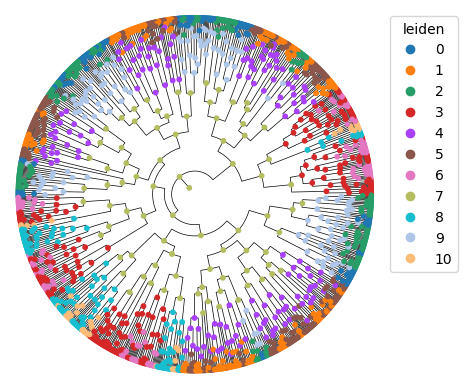

In [ ]:
py.pl.tree(trajectory_data, polar=True, node_color="leiden", nodes="all", depth_key="time");

# Manually specified trajectory

For even more control, we can explicitly define the cell-state trajectory used by {func}`cassiopeia.sim.trajectory_expression`. Here, we construct a trajectory tree manually with [networkX](https://networkx.org/documentation/stable/install.html), assign each state a pseudotime, and add branch probabilities that determine how cells choose between alternative fate paths.

We then use {func}cassiopeia.sim.brownian_expression to assign latent coordinates to the trajectory nodes. These latent coordinates define the expression programs associated with each state, while the edge probabilities define the relative likelihood of each fate transition.

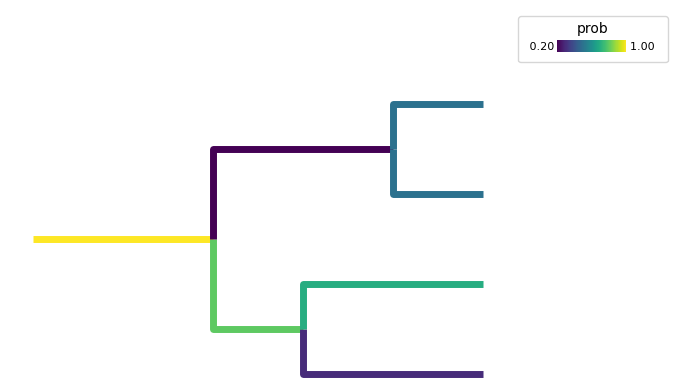

In [57]:
custom_trajectory = nx.DiGraph()
custom_trajectory.add_edges_from(
    [("root", "0"), ("0", "1"), ("0", "2"), ("1", "3"), ("1", "4"), ("2", "5"), ("2", "6")]
)
nx.set_node_attributes(
    custom_trajectory,
    {"root": 0, "0": 0.4, "1": 0.6, "2": 0.8, "3": 1, "4": 1, "5": 1, "6": 1},
    "time",
)
nx.set_edge_attributes(
    custom_trajectory,
    {
        ("root", "0"): 1,
        ("0", "1"): 0.8,
        ("0", "2"): 0.2,
        ("1", "3"): 0.3,
        ("1", "4"): 0.7,
        ("2", "5"): 0.5,
        ("2", "6"): 0.5,
    },
    "prob",
)
custom_trajectory = td.TreeData(obst={"tree": custom_trajectory}, alignment="nodes")
custom_trajectory = cas.sim.brownian_expression(custom_trajectory, momentum=0.95)
py.pl.tree(custom_trajectory, branch_color="prob", depth_key="time", branch_linewidth=5)
trajectory_data = cas.sim.trajectory_expression(
    tdata, custom_trajectory, random_seed=42, latent_noise=0.2, prob_key="prob"
)

Now the number of cells following each trajectory branch is determined by the specified edge probabilities, allowing us to simulate scenarios where certain fates are more common than others.

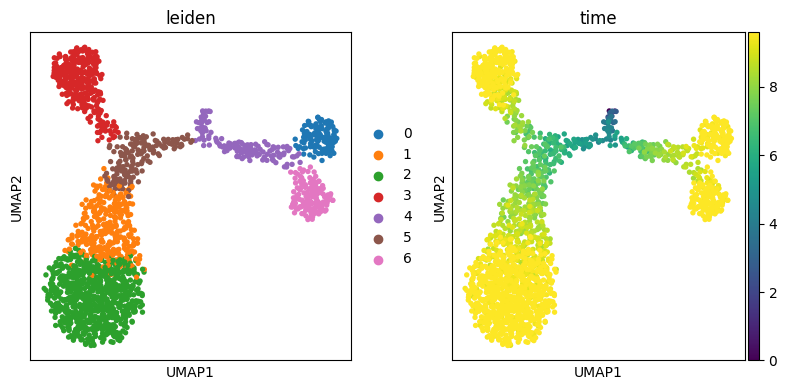

In [58]:
sc.pp.pca(trajectory_data)
sc.pp.neighbors(trajectory_data)
sc.tl.umap(trajectory_data)
sc.tl.leiden(trajectory_data, flavor="igraph")
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
sc.pl.umap(trajectory_data, color="leiden", ax=axes[0], show=False)
sc.pl.umap(trajectory_data, color="time", ax=axes[1], show=False)
fig.tight_layout()